<a href="https://colab.research.google.com/github/salometoroc-cmd/Estructura-de-bases-de-datos-/blob/main/Lab%202%20Arboles%20KD/laboratorio_arboles_kd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Salomé Toro Cadavid

14/04/2026

# Arbol KD

Un arbol KD, es una árbol que organiza en varias dimensiones k en un espacio a un punto, permitiendo búsquedas rápidas.


El Árbol que se presenta está contruido en estructura de programacion orienta objetos, cuenta con:


**Clase nodo:**

 Donde definimos un punto, eleje por el cual se divide el árbol dependiendo de su dimención y los los subárboles izquierdo y derecho.


**Clase ArbolKD:**

 Se presenta la contruccion de arbol apartir  de una cantidad de datos presentados como tuplas las cuales son su dirección . Para construirlo se lececciona un eje según la profundidad , se orden las los puntos por ese eje y se toma la mediana de ellos como raíz.Los puntos a la izquierda de esta van al subárbol izquiero y los puentos al laldo derecho al subárbol derecho, esto se repite cambiando de eje para cumplir con la estructura de estos árboles.

 para hayar la mediana consideramos una distribución homogénea, donde organizamos los datos y luego la hayamos , pero para tener en cuenta que para una distribucion no tan homogenea pueden haber algunos errores.


dentro de esta clase del arbol:

 **buscamos por radio:**

  definiendo un radio para encerrar aquello puntos que estan dentro, para ello se van eliminando aquellas ramas que hacen parte del eje .

 **función del vecino más cercano :**

consiste en contrar el vecino más cercano posible a nuestra posición en un punto p, para ello medimos distancia al eje para ver si se va a otra rama .

In [ ]:
class Nodo:
    def __init__(self,punto,eje):
      self.punto = punto
      self.eje = eje
      self.izquierdo = None
      self.derecho = None

class ArbolKD:
    def __init__(self, puntos): # los puntos son aquellos que  componen de un "x" y "y"  como (5,2)
      self.k = len(puntos[0])  # la dimensión
      self.raiz = self.construir(puntos, profundidad = 0)
#construir el arbol
    def construir(self, puntos, profundidad):
      if not puntos :  #si no hay puntos no se hace nda
          return None
      eje = profundidad % self.k   #para un eje cualquiera de dimesión k los alterna
      puntos = sorted(puntos , key=lambda x: x[eje])
      mediana = len(puntos)//2  # ya ordenados los puntos se calcula la mediana(esto está incorrecto pero funciona para el árbol ya que los puntos ya están organizados )
      mediana_nodo = puntos[mediana]
      nodo = Nodo(mediana_nodo,eje)    #la mediana se vuelve la raiz y se organizan los demás puntos
      nodo.izquierdo = self.construir(puntos[:mediana], profundidad + 1) #se usa recursión para construir el arbol
      nodo.derecho = self.construir(puntos[mediana +1 :], profundidad + 1)
      return nodo

    def buscarporRadio(self ,nodo,p, radio,lista ):  #buscar por el radio puntos dentro
      if nodo is None:
        return
      distancia = (p[0] - nodo.punto[0])**2 + (p[1] - nodo.punto[1])**2  #para hallar distancia se usa la formula general

      if distancia <= radio**2: # solo si el punto está dentro del radio entra
        lista.append(nodo.punto)
      eje = nodo.eje

      if p[eje] < nodo.punto[eje]: # explora lado al cual pertenece el punto p
        self.buscarporRadio(nodo.izquierdo, p, radio, lista)
      else:
        self.buscarporRadio(nodo.derecho, p, radio, lista)

      distancia_eje = abs(p[eje] - nodo.punto[eje])

      if distancia_eje <= radio:
        if p[eje] < nodo.punto[eje]:
            self.buscarporRadio(nodo.derecho, p, radio, lista)
        else:
            self.buscarporRadio(nodo.izquierdo, p, radio, lista)

    def buscarVecinoCercanos(self,p,nodo,cercano):
      if nodo == None:
        return
      distancia = (p[0] - nodo.punto[0])**2 + (p[1] - nodo.punto[1])**2   #distancia usando las coordenadas al nodo actual
      if distancia < cercano["distancia_mejorvecino"]:    #si hay un vecino más cercano se cambia
        cercano["distancia_mejorvecino"] = distancia
        cercano["mejor_punto"]= nodo.punto

      eje = nodo.eje
      if p[eje] < nodo.punto[eje]:
        self.buscarVecinoCercanos(p,nodo.izquierdo,cercano)
      else:
        self.buscarVecinoCercanos(p,nodo.derecho,cercano)

      distancia_eje = (p[eje] - nodo.punto[eje])**2   #encuentra la distancia al eje para comparar
      if distancia_eje < cercano["distancia_mejorvecino"]:
        if p[eje] < nodo.punto[eje]:   #dependiendo de esto sobre si se ve el otro lado
          self.buscarVecinoCercanos(p,nodo.derecho,cercano)
        else:
          self.buscarVecinoCercanos(p,nodo.izquierdo,cercano)


# Test

##Fuerza bruta

La fuerza bruta para el ejercicio se ha realizado mediante listas, debido a su diferencia con respecto a los árboles.

Para ellos generamos dos funciones:

Para buscar por radio, usamos los puntos que tenemos de la cantidad de datos, usamos nuestro punto objetivo llamado p y el radio. Para crear el radio, usamos radio al cuadrado para no tener que usar una raiz, y para cada punto en los puntos de los datos, recorremos las distancias; aquellos más cerca y dentro del radio quedan y los demás se descartan. Punto p: para ello medimos distancia e igualmente comparamos.

In [ ]:
def fuerza_bruta_buscar_radio(puntos, p, radio):
  global tiempo_final_fbuscar
  import time
  radio_cuadrado = radio**2
  resultados = []
  inicio = time.perf_counter() #inicia a medir tiempo
  for punto in puntos: #recorremos todos los puntos
    distancia = (p[0] - punto[0])**2 + (p[1] - punto[1])**2 #se calcula las distancia
    if distancia <= radio_cuadrado:  # si está dentro del radio queda
      resultados.append(punto)
  fin = time.perf_counter()
  print(resultados)
  tiempo_final_fbuscar =  fin - inicio


def fuerza_bruta_buscar_vecino_cercano(puntos, p):
  global tiempo_final_fvecino
  import time
  inicio = time.perf_counter()
  mejor_distancia = float("inf")
  mejor_punto = None
  for punto in puntos:  # en los puntos so hay una distancia más cercana se cambia
    distancia = (p[0] - punto[0])**2 + (p[1] - punto[1])**2
    if distancia < mejor_distancia:
      mejor_distancia = distancia
      mejor_punto = punto
  fin = time.perf_counter()
  tiempo_final_fvecino =  fin - inicio
  print("El punto más cercano es decir el vecino más cercano es: ", mejor_punto)
  print("Distancia:", mejor_distancia)

##**Ejemplo:**

Para el ejemplo, se generan los puntos aleatorios; se escoge como punto objetivo en la variable p al punto encontrado en la dirección (2000,5000) se tiene presente el radio el cual es 500; se llama al árbol para construirlo e igualmente a las funciones de fuerza bruta.

se imprime solo lo de fuerza bruta debido a que los resluados de el arbol se veran más adelante.




In [ ]:
import random
puntos = [(random.randint(0,10000), random.randint(0,10000)) for _ in range(10000)]
arbol = ArbolKD(puntos)
p = (2000,5000)
print("fuerza bruta radio")
fuerza_bruta_buscar_radio(puntos, p, 500)

print("fuerza bruta vecino más cercano y distancia")
fuerza_bruta_buscar_vecino_cercano(puntos, p)

fuerza bruta radio
[(1597, 4874), (1589, 4774), (2113, 4640), (2068, 5284), (1782, 4561), (2056, 5486), (1835, 4908), (2218, 5131), (2034, 4815), (2131, 5396), (1904, 4724), (1673, 4858), (1835, 5448), (1798, 5379), (2343, 4908), (1842, 5350), (1552, 4877), (2174, 4668), (1737, 4748), (1533, 4884), (2139, 4880), (1561, 5209), (2463, 4846), (2124, 5106), (1737, 5007), (1877, 4579), (2149, 4741), (1680, 4812), (2045, 5267), (1532, 5078), (2310, 4897), (2029, 4790), (1862, 4878), (2175, 4943), (2386, 5008), (2319, 5168), (1739, 5100), (2355, 4758), (1507, 5063), (1919, 4553), (2347, 5145), (1999, 5272), (1918, 5455), (2153, 5002), (1815, 4959), (2372, 5329), (1830, 5023), (2269, 5099), (2264, 5008), (2131, 4623), (2034, 5097), (1911, 4900), (2446, 5066), (1593, 4762), (1787, 4988), (2055, 4730), (2442, 4950), (1883, 5448), (1769, 5208), (1835, 4840), (1879, 5201), (2198, 4978), (2368, 5086), (2136, 5148), (1558, 4977), (2111, 5390), (1641, 5028), (2014, 4696), (2280, 5060), (2409, 5069)]


##Gráfica buscar por radio



Observamos que se muestran todos los puntos creados aleatoriamente de color azul; los puntos dentro del radio son los rosados y están dentro de un círculo que representa ese radio, y el punto amarillo es nuestro punto (2000,5000).




Esto representa que, al realizar la función de buscar, el árbol debe comparar y buscar en ambos lados, izquierdo y derecho, quiénes son aquellos puntos que se encuentran dentro del radio elegido, también comparando distancias.

[(2280, 5060), (2068, 5284), (2136, 5148), (2045, 5267), (2124, 5106), (2034, 5097), (1999, 5272), (2269, 5099), (2264, 5008), (2153, 5002), (2218, 5131), (2131, 5396), (2111, 5390), (2056, 5486), (2372, 5329), (2409, 5069), (2347, 5145), (2386, 5008), (2368, 5086), (2319, 5168), (2446, 5066), (1798, 5379), (1769, 5208), (1879, 5201), (1830, 5023), (1787, 4988), (1842, 5350), (1739, 5100), (1737, 5007), (1641, 5028), (1883, 5448), (1835, 5448), (1918, 5455), (1532, 5078), (1507, 5063), (1561, 5209), (1835, 4840), (2139, 4880), (2131, 4623), (2014, 4696), (1911, 4900), (1835, 4908), (1904, 4724), (1862, 4878), (2029, 4790), (2034, 4815), (2113, 4640), (2055, 4730), (1919, 4553), (1877, 4579), (2174, 4668), (2343, 4908), (2175, 4943), (2198, 4978), (2310, 4897), (2149, 4741), (2463, 4846), (2442, 4950), (2355, 4758), (1597, 4874), (1673, 4858), (1815, 4959), (1680, 4812), (1533, 4884), (1558, 4977), (1552, 4877), (1782, 4561), (1737, 4748), (1593, 4762), (1589, 4774)]


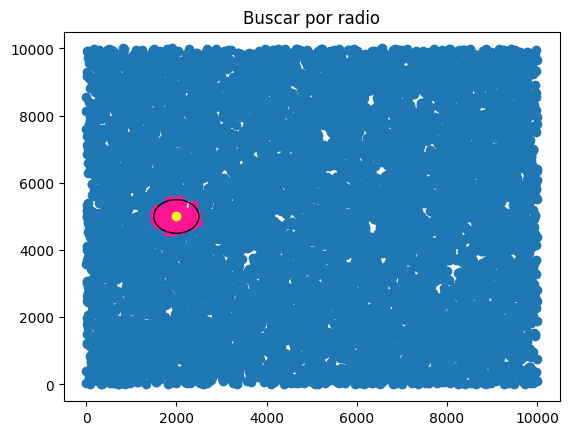

In [ ]:
punto = (2000,5000)
radio = 500
resultados = []
inicio = time.perf_counter()
arbol.buscarporRadio(arbol.raiz, punto, radio, resultados)
fin = time.perf_counter()
tiempo_final_buscarRadio = fin - inicio
print(resultados)

import matplotlib.pyplot as plt

x = []  #listas vacias para los puntos
y = []
for p in puntos:
    x.append(p[0])
    y.append(p[1])
x_radio = [] # puntos solo dentro del radio
y_radio = []
for p in resultados:
    x_radio.append(p[0])
    y_radio.append(p[1])

plt.scatter(x, y) # todos los puntos es decir los 10000
plt.scatter(x_radio, y_radio, color = "deeppink")#puntos alrededor dentro del radio
plt.scatter(punto[0], punto[1], color="yellow")# nuestro punto p

circulo = plt.Circle((punto[0], punto[1]), radio, fill=False)#  círculo del radio
plt.gca().add_patch(circulo)
plt.title("Buscar por radio")
plt.show()

##Gráfica abrol KD vecino más cercano


Para este usamos la función de vecino más cercano, donde se usa la función de buscar el vecino más cercano que tiene el árbol. En ella logramos ver a los puntos que son los rosados, encontrando a nuestro punto p o el punto que tenemos como objetivo o consulta de color naranja y, por último, encontramos al vecino que será a través del color verde, y la distancia que hay entre ambos puntos la encontramos de color amarillo.




Lo que representa el gráfico en este ejemplo es que el punto más cercano es el (1994, 4983) y se encuentra a una distancia bastante corta de 325.


El punto más cercano es decir el vecino más cercano es:  (2034, 5097)
Distancia: 10565


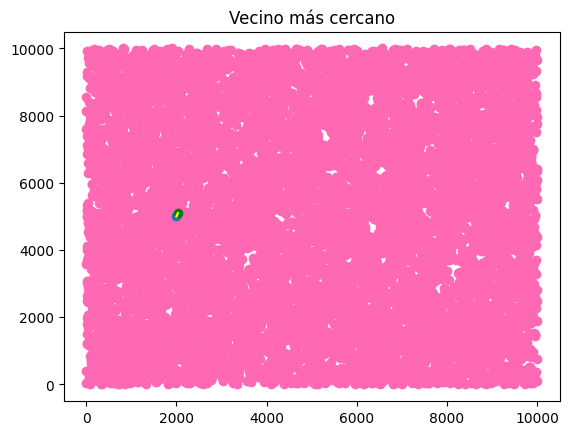

In [ ]:
import time  # se mide el tiempo inicial y final para obtener el total
punto = (2000,5000)
cercano = {"distancia_mejorvecino": float("inf"),"mejor_punto": None}
inicio = time.perf_counter()
arbol.buscarVecinoCercanos(punto, arbol.raiz, cercano)
fin = time.perf_counter()
tiempo_final_vecinoCercano = fin - inicio
print("El punto más cercano es decir el vecino más cercano es: ", cercano["mejor_punto"])
print("Distancia:", cercano["distancia_mejorvecino"])

import matplotlib.pyplot as plt
vecino = cercano["mejor_punto"]
x = []   #puntos
y = []
for p in puntos:
    x.append(p[0])
    y.append(p[1])

plt.scatter(x, y ,color="hotpink" ) # todos los puntos
plt.scatter(punto[0], punto[1])# punto consulta es decir p
plt.scatter(vecino[0], vecino[1], color="green")# vecino más cercano
plt.plot([punto[0], vecino[0]], [punto[1], vecino[1]], color="yellow")# distancia dibujada
plt.title("Vecino más cercano")
plt.show()

##Tiempos de comparación

Para los tiempos de comparación se realiza el cálculo de tiempo al llamar a cada una de las funciones para el árbol al crear los gráficos, cuando llama a las funciones, y para la fuerza bruta en las mismas funciones.

Explicación comparaciones:

Para este ejercicio se tomó el ejemplo del punto (2000, 5000), se consideró un radio constante de 500 y se realizó la comparación con distintas cantidades de datos, las cuales fueron 100, 1000, 5000, 10000, que es lo que oficialmente pide el ejercicio, y 20000, esto con la finalidad de ver cómo responde el árbol con respecto a la fuerza bruta.

Para cada uno de los datos se ejecutó todo el código 3 veces, esto para sacar un promedio que será de ayuda al entender los tiempos, y se realizó un cuadro comparativo con estos resultados.



árbol

In [ ]:
print("tiempo de busqueda de radio con el arbol KD: " , f"{tiempo_final_buscarRadio:.8f}")
print("tiempo de vecino más cercano con árbol KD: ", f"{tiempo_final_vecinoCercano:.8f}")

fuerza bruta

In [ ]:
print("tiempo de busqueda de radio con fuerza bruta: " ,f"{tiempo_final_fbuscar:.8f}")
print("tiempo de vecino más cercano con fuerza bruta ", f"{tiempo_final_fvecino:.8f}")

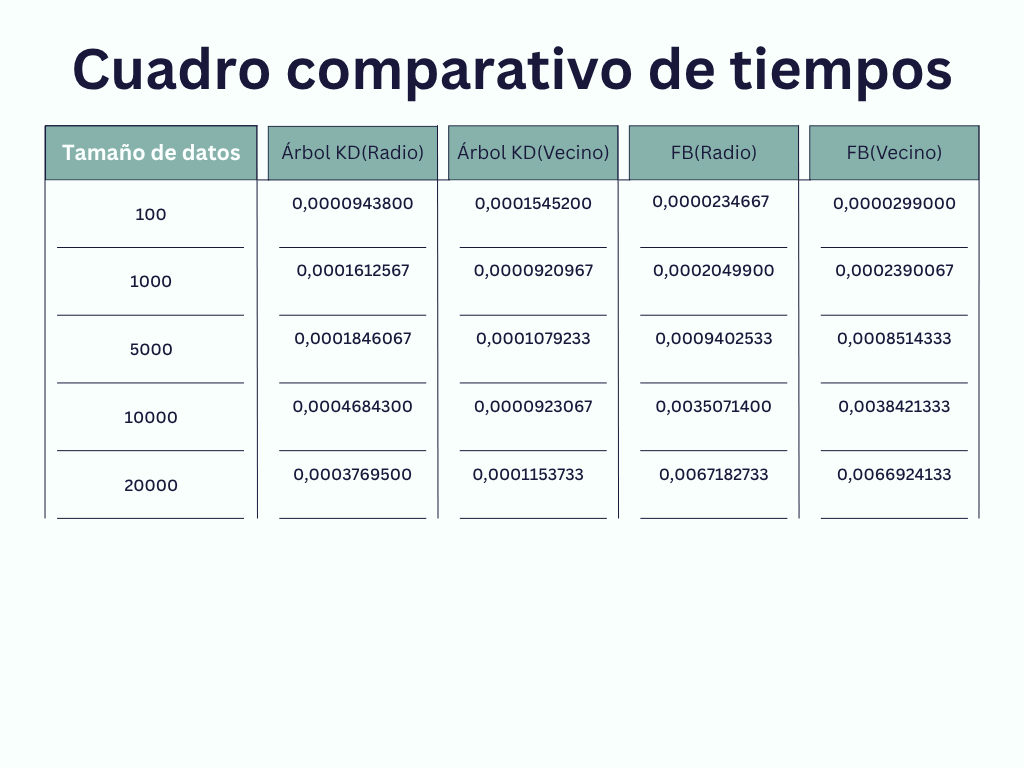

# Analisis resultados

Para el árbol se considera que la distribución es homogénea y, al realizarla de esta forma, ordenamos los datos y encontramos un aproximado de lo que sería la mediana.

Se verificó que el árbol funciona medianamente bien debido a que en fuerza bruta se obtienen los mismos resultados para las consultas realizadas.


 Para responder la pregunta:**¿Para qué tamaño de datos el árbol KD comienza a ser más rápido que "fuerza bruta"?**

Para el árbol se logra visualizar que llega a ser más rápido con 1000 datos, y no cuando hay menos datos. Por lo que, al tener mayor número de datos, es más posible mayor rapidez, sabiendo que aquí consideramos 2 dimensiones; en otro caso no será igual, se convierte en ineficiente por las búsquedas extensas.

##Dificultades y Errores

-Para hallar la mediana, consideramos una distribución homogénea, donde organizamos los datos y luego la hallamos, pero para tener en cuenta que para una distribución no tan homogénea pueden haber algunos errores.




-Encontrar una lógica correcta al construir el árbol.




-Un error corregido es el cálculo de fuerza bruta y el árbol donde, debido a hacer los datos aleatorios dos veces, no coincidían los datos.

-posible error al calcular promedios para el cuadro comparativo de los tiempos debido al los malos calculos o errores en algunos números

Referencia

https://www-baeldung-com.translate.goog/cs/k-d-trees?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc

https://www-tutorialspoint-com.translate.goog/data_structures_algorithms/k_d_trees.htm?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=wa